# 02 - Embedding and FAISS exploration

## Purpose

This notebook records the evidence needed to choose the baseline embedding model and FAISS index configuration. It is deliberately read-only: it inspects the validated chunk export, measures its token volume, checks the installed APIs and runs a synthetic FAISS test. **It does not call the OpenAI API and does not create production embeddings.**

The intended outputs are evidence for a later frozen configuration, reusable implementation and automated tests. Generated embeddings and indexes must remain outside Git because they are derived from copyrighted source text.

## Replication boundary

Tophel et al. (2025), Table 2, reports that document chunks were embedded with OpenAI embeddings and stored in FAISS. The paper does not report the exact embedding model, vector dimension, normalisation step, FAISS index class, distance metric, batch size or retrieval depth. Those values therefore require transparent reconstruction rather than being presented as exact replication.

The local API inventory adds an important replication clue: the installed `OpenAIEmbeddings` class defaults to `text-embedding-ada-002`. This does not prove which model the authors used, but it is the closest reproducible interpretation of an unspecified `OpenAIEmbeddings()` call in the reported LangChain workflow. Current OpenAI documentation identifies `text-embedding-ada-002` as an older 1,536-dimensional model. It also states that `text-embedding-3-small` produces 1,536-dimensional vectors by default and `text-embedding-3-large` produces 3,072-dimensional vectors by default.

OpenAI recommends cosine similarity and states that its embeddings are normalised to length 1, so dot product gives the same ranking as cosine similarity. The tokenizer is resolved locally with `tiktoken.encoding_for_model` rather than assumed.

Official sources checked on 2026-09-08:

- https://developers.openai.com/api/docs/guides/embeddings
- https://developers.openai.com/api/docs/models/text-embedding-ada-002
- https://developers.openai.com/api/docs/models/text-embedding-3-small
- https://developers.openai.com/api/docs/models/text-embedding-3-large

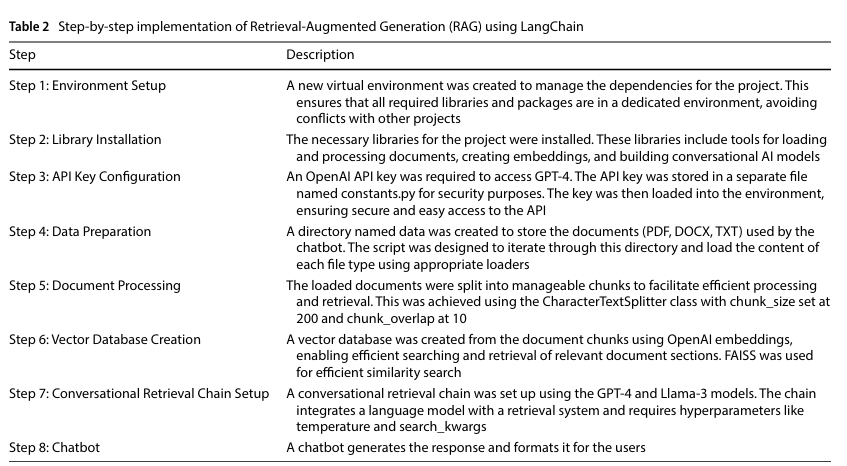

In [1]:
from __future__ import annotations

from hashlib import sha256
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path
import inspect
import json
import math
import os
import statistics
import tempfile

import faiss
import numpy as np
import tiktoken
from langchain_openai import OpenAIEmbeddings
from openai.resources.embeddings import Embeddings


def locate_project_root() -> Path:
    """Locate the repository from either its root or notebooks directory."""

    candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent]

    for candidate in candidates:
        if (candidate / "pyproject.toml").is_file() and (
            candidate / "configs" / "chunking-config.json"
        ).is_file():
            return candidate

    raise RuntimeError(
        "Run this notebook from the repository root or its notebooks directory."
    )


def file_sha256(path: Path) -> str:
    """Calculate a file fingerprint without changing the file."""

    digest = sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def env_file_defines_key(path: Path, key: str) -> bool:
    """Check only whether a key name exists; never print its value."""

    if not path.is_file():
        return False

    for raw_line in path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        name = line.split("=", 1)[0].strip()
        if name.startswith("export "):
            name = name.removeprefix("export ").strip()
        if name == key:
            return True

    return False


PROJECT_ROOT = locate_project_root()
CHUNKS_PATH = PROJECT_ROOT / "data/processed/corpus/chunks.jsonl"
SUMMARY_PATH = PROJECT_ROOT / "data/processed/audit/chunking-summary.json"
CHUNKING_CONFIG_PATH = PROJECT_ROOT / "configs/chunking-config.json"

for required_path in [CHUNKS_PATH, SUMMARY_PATH, CHUNKING_CONFIG_PATH]:
    if not required_path.is_file():
        raise RuntimeError(f"Required file is missing: {required_path}")

print("Project root:", PROJECT_ROOT)
print("OPENAI_API_KEY exported in process:", bool(os.getenv("OPENAI_API_KEY")))
print("OPENAI_API_KEY named in .env:", env_file_defines_key(PROJECT_ROOT / ".env", "OPENAI_API_KEY"))
print("No credential value was read or displayed.")

Project root: /home/zaki/coding_F/GismaProjects/Thesis
OPENAI_API_KEY exported in process: True
OPENAI_API_KEY named in .env: True
No credential value was read or displayed.


## 1. Installed dependency and API inventory

This cell records the locally installed versions and the relevant constructor/API surface. It does not instantiate an API client.

In [2]:
PACKAGE_NAMES = [
    "openai",
    "langchain-openai",
    "faiss-cpu",
    "numpy",
    "tiktoken",
]

print("Installed embedding and retrieval packages:")
for package_name in PACKAGE_NAMES:
    try:
        package_version = version(package_name)
    except PackageNotFoundError:
        package_version = "NOT INSTALLED"
    print(f"  {package_name}: {package_version}")

print()
print("OpenAIEmbeddings signature:")
print(inspect.signature(OpenAIEmbeddings))
print()
print("OpenAI embeddings.create signature:")
print(inspect.signature(Embeddings.create))

relevant_fields = [
    "model",
    "dimensions",
    "chunk_size",
    "max_retries",
    "request_timeout",
    "show_progress_bar",
    "skip_empty",
    "check_embedding_ctx_length",
    "tiktoken_enabled",
    "tiktoken_model_name",
]

print()
print("Selected OpenAIEmbeddings field defaults:")
for field_name in relevant_fields:
    field = OpenAIEmbeddings.model_fields.get(field_name)
    if field is None:
        print(f"  {field_name}: FIELD NOT PRESENT")
    else:
        print(f"  {field_name}: {field.default!r}")

print()
print("FAISS API availability:")
for name in ["IndexFlatIP", "IndexFlatL2", "normalize_L2", "write_index", "read_index"]:
    print(f"  {name}: {hasattr(faiss, name)}")

Installed embedding and retrieval packages:
  openai: 2.53.0
  langchain-openai: 1.4.2
  faiss-cpu: 1.15.0
  numpy: 2.5.1
  tiktoken: 0.13.0

OpenAIEmbeddings signature:
(*, client: Any = None, async_client: Any = None, model: str = 'text-embedding-ada-002', dimensions: int | None = None, deployment: str | None = 'text-embedding-ada-002', api_version: str | None = <factory>, base_url: str | None = <factory>, openai_api_type: str | None = <factory>, openai_proxy: str | None = <factory>, embedding_ctx_length: int = 8191, api_key: pydantic.types.SecretStr | None | collections.abc.Callable[[], str] | collections.abc.Callable[[], collections.abc.Awaitable[str]] = <factory>, organization: str | None = <factory>, allowed_special: Union[Literal['all'], set[str], NoneType] = None, disallowed_special: Union[Literal['all'], set[str], collections.abc.Sequence[str], NoneType] = None, chunk_size: int = 1000, max_retries: int = 2, timeout: float | tuple[float, float] | typing.Any | None = None, heade

## 2. Validated chunk input

The embedding stage must consume the already validated chunk export without rewriting it. This cell verifies its fingerprint against the chunking summary and loads only the JSONL records required for the audit.

In [3]:
chunking_summary = json.loads(SUMMARY_PATH.read_text(encoding="utf-8"))
chunking_config = json.loads(CHUNKING_CONFIG_PATH.read_text(encoding="utf-8"))
actual_chunks_sha256 = file_sha256(CHUNKS_PATH)

if actual_chunks_sha256 != chunking_summary["chunks_sha256"]:
    raise RuntimeError("The chunk export fingerprint does not match its summary.")

with CHUNKS_PATH.open("r", encoding="utf-8") as handle:
    chunk_records = [json.loads(line) for line in handle if line.strip()]

if len(chunk_records) != chunking_summary["chunk_count"]:
    raise RuntimeError("The chunk record count does not match its summary.")

chunk_ids = [record["chunk_id"] for record in chunk_records]
chunk_texts = [record["text"] for record in chunk_records]

if len(chunk_ids) != len(set(chunk_ids)):
    raise RuntimeError("Chunk identifiers are not unique.")
if any(not isinstance(text, str) or not text for text in chunk_texts):
    raise RuntimeError("Every chunk must contain non-empty text.")

print("Validated chunk input:")
print("  Records:", len(chunk_records))
print("  Total characters:", sum(len(text) for text in chunk_texts))
print("  Chunks SHA-256:", actual_chunks_sha256)
print("  First chunk ID:", chunk_ids[0])
print("  Last chunk ID:", chunk_ids[-1])
print("  Unique chunk IDs:", len(set(chunk_ids)))

Validated chunk input:
  Records: 5113
  Total characters: 848280
  Chunks SHA-256: bce9702308a65b9e9ab3bcdb0781ad308d509b56904a95ec7bab4feffebca645
  First chunk ID: das-sobhan-2014-8e-si:pdf-0025:region-00:chunk-0000
  Last chunk ID: das-sobhan-2014-8e-si:pdf-0737:region-00:chunk-0010
  Unique chunk IDs: 5113


## 3. Token volume and cost estimate

The official guide specifies `cl100k_base` for third-generation embedding models. Token counts are calculated locally. The displayed API prices are planning values from the official model pages checked on 2026-09-08 and must be rechecked before a paid production run. No request is sent by this cell.

In [4]:
ENCODING_NAME = "cl100k_base"
MODEL_INPUT_LIMIT = 8192
PRICE_PER_MILLION_TOKENS_USD = {
    "text-embedding-ada-002": 0.10,
    "text-embedding-3-small": 0.02,
    "text-embedding-3-large": 0.13,
}

model_encoding_names = {
    model_name: tiktoken.encoding_for_model(model_name).name
    for model_name in PRICE_PER_MILLION_TOKENS_USD
}
if model_encoding_names["text-embedding-ada-002"] != ENCODING_NAME:
    raise RuntimeError("Unexpected tokenizer for text-embedding-ada-002.")

encoding = tiktoken.get_encoding(ENCODING_NAME)
token_counts = [len(encoding.encode(text)) for text in chunk_texts]
sorted_token_counts = sorted(token_counts)


def nearest_rank_percentile(values: list[int], percentile: float) -> int:
    """Return the nearest-rank percentile for a non-empty integer list."""

    if not values:
        raise ValueError("Cannot calculate a percentile for an empty list.")
    rank = max(1, math.ceil(percentile * len(values)))
    return sorted(values)[rank - 1]


total_tokens = sum(token_counts)
duplicate_text_occurrences = len(chunk_texts) - len(set(chunk_texts))
oversized_token_inputs = sum(count > MODEL_INPUT_LIMIT for count in token_counts)

print("Local token audit:")
print("  Encoding:", ENCODING_NAME)
print("  Model encoding map:", model_encoding_names)
print("  Chunks:", len(token_counts))
print("  Total tokens:", total_tokens)
print("  Token count min:", min(token_counts))
print("  Token count mean:", round(statistics.mean(token_counts), 3))
print("  Token count median:", statistics.median(token_counts))
print("  Token count p95:", nearest_rank_percentile(token_counts, 0.95))
print("  Token count max:", max(token_counts))
print("  Inputs over 8,192 tokens:", oversized_token_inputs)
print("  Duplicate text occurrences:", duplicate_text_occurrences)
print("  Characters per token:", round(sum(map(len, chunk_texts)) / total_tokens, 3))

print()
print("Estimated one-pass corpus embedding cost (USD):")
for model_name, price in PRICE_PER_MILLION_TOKENS_USD.items():
    estimate = total_tokens / 1_000_000 * price
    print(f"  {model_name}: ${estimate:.6f}")

largest = sorted(
    zip(token_counts, chunk_ids, strict=True),
    reverse=True,
)[:10]
print()
print("Ten largest chunks by token count (text intentionally omitted):")
for token_count, chunk_id in largest:
    print(f"  {token_count:4d} | {chunk_id}")


Local token audit:
  Encoding: cl100k_base
  Model encoding map: {'text-embedding-ada-002': 'cl100k_base', 'text-embedding-3-small': 'cl100k_base', 'text-embedding-3-large': 'cl100k_base'}
  Chunks: 5113
  Total tokens: 303045
  Token count min: 2
  Token count mean: 59.27
  Token count median: 48
  Token count p95: 135
  Token count max: 183
  Inputs over 8,192 tokens: 0
  Duplicate text occurrences: 5
  Characters per token: 2.799

Estimated one-pass corpus embedding cost (USD):
  text-embedding-ada-002: $0.030305
  text-embedding-3-small: $0.006061
  text-embedding-3-large: $0.039396

Ten largest chunks by token count (text intentionally omitted):
   183 | das-sobhan-2014-8e-si:pdf-0628:region-00:chunk-0002
   183 | das-sobhan-2014-8e-si:pdf-0583:region-00:chunk-0004
   183 | das-sobhan-2014-8e-si:pdf-0583:region-00:chunk-0003
   177 | das-sobhan-2014-8e-si:pdf-0628:region-00:chunk-0001
   176 | das-sobhan-2014-8e-si:pdf-0657:region-00:chunk-0002
   174 | das-sobhan-2014-8e-si:pdf-0

## 4. Synthetic FAISS metric and persistence audit

For only 5,113 chunks, exact flat search is practical and removes approximation parameters from the baseline. This synthetic test checks that `IndexFlatIP` on unit-normalised vectors gives the same ranking as `IndexFlatL2`, and that a saved index reloads without changing its results. The vectors below are synthetic and unrelated to the textbook.

In [5]:
vectors = np.asarray(
    [
        [1.0, 0.0, 0.0],
        [0.8, 0.2, 0.0],
        [0.2, 0.8, 0.0],
        [0.0, 0.0, 1.0],
    ],
    dtype=np.float32,
)
query = np.asarray([[0.9, 0.1, 0.0]], dtype=np.float32)
faiss.normalize_L2(vectors)
faiss.normalize_L2(query)

ip_index = faiss.IndexFlatIP(vectors.shape[1])
l2_index = faiss.IndexFlatL2(vectors.shape[1])
ip_index.add(vectors)
l2_index.add(vectors)

ip_scores, ip_positions = ip_index.search(query, len(vectors))
l2_distances, l2_positions = l2_index.search(query, len(vectors))

if not np.array_equal(ip_positions, l2_positions):
    raise RuntimeError("Inner-product and L2 rankings differ for normalised vectors.")

with tempfile.TemporaryDirectory() as temporary_directory:
    index_path = Path(temporary_directory) / "synthetic.index"
    faiss.write_index(ip_index, str(index_path))
    reloaded_index = faiss.read_index(str(index_path))
    reloaded_scores, reloaded_positions = reloaded_index.search(
        query, len(vectors)
    )

if not np.array_equal(ip_positions, reloaded_positions):
    raise RuntimeError("FAISS positions changed after index reload.")
if not np.array_equal(ip_scores, reloaded_scores):
    raise RuntimeError("FAISS scores changed after index reload.")

print("Synthetic FAISS audit:")
print("  Vector dtype:", vectors.dtype)
print("  Dimensions:", vectors.shape[1])
print("  IndexFlatIP positions:", ip_positions[0].tolist())
print("  IndexFlatIP scores:", ip_scores[0].tolist())
print("  IndexFlatL2 positions:", l2_positions[0].tolist())
print("  IndexFlatL2 distances:", l2_distances[0].tolist())
print("  Rankings identical:", np.array_equal(ip_positions, l2_positions))
print("  Reload positions identical:", np.array_equal(ip_positions, reloaded_positions))
print("  Reload scores identical:", np.array_equal(ip_scores, reloaded_scores))
print("Synthetic FAISS audit: PASSED")

Synthetic FAISS audit:
  Vector dtype: float32
  Dimensions: 3
  IndexFlatIP positions: [0, 1, 2, 3]
  IndexFlatIP scores: [0.9938837289810181, 0.9909924268722534, 0.34818652272224426, 0.0]
  IndexFlatL2 positions: [0, 1, 2, 3]
  IndexFlatL2 distances: [0.012232531793415546, 0.018015138804912567, 1.3036268949508667, 2.0]
  Rankings identical: True
  Reload positions identical: True
  Reload scores identical: True
Synthetic FAISS audit: PASSED


## 5. Preliminary baseline candidate

The following is a candidate, not yet a frozen configuration. The model choice is an explicitly labelled inference because the paper does not report the embedding identifier.

| Decision | Candidate | Reason |
|---|---|---|
| Embedding model | `text-embedding-ada-002` | The paper reports LangChain plus OpenAI embeddings but gives no model. The installed `OpenAIEmbeddings` default is `text-embedding-ada-002`, making it the closest reproducible baseline assumption. This remains an inference, not a reported paper value. |
| Dimensions | Default `1536`; omit the API `dimensions` argument | Preserves the model default and avoids adding an undocumented dimension-reduction choice. |
| Token encoding | Resolve with `tiktoken.encoding_for_model`; expected `cl100k_base` | Ties counting to the selected model rather than a handwritten assumption. |
| Vector dtype | `float32` | Native FAISS input type and reproducible storage. |
| Normalisation | Validate API norms, then explicitly L2-normalise the `float32` indexing matrix | Makes the cosine-equivalent condition explicit and protects it after dtype conversion. |
| FAISS index | `IndexFlatIP` | Exact, parameter-free nearest-neighbour search is suitable for 5,113 vectors. With unit vectors, inner product equals cosine similarity. |
| ID mapping | Ordered index-position-to-`chunk_id` mapping | Preserves deterministic provenance from each returned vector to its chunk. |
| `text-embedding-3-small` | Optional later sensitivity study, not the replication baseline | It is newer and cheaper, but silently substituting it would weaken the reconstruction of the paper's LangChain workflow. Changing the embedding model also requires a separate index. |

Retrieval depth `k` remains unresolved. It should be selected through retrieval evaluation against the question set, not guessed during index construction.


In [6]:
preliminary_candidate = {
    "decision_status": "candidate_pending_api_smoke_test",
    "decision_evidence": "paper_unspecified_installed_langchain_default",
    "embedding_model": "text-embedding-ada-002",
    "embedding_dimensions": 1536,
    "dimensions_api_argument": None,
    "token_encoding": ENCODING_NAME,
    "vector_dtype": "float32",
    "normalisation": "explicit_l2_before_indexing",
    "faiss_index_class": "IndexFlatIP",
    "similarity_interpretation": "cosine_similarity_for_unit_vectors",
    "retrieval_k": None,
    "input_chunk_count": len(chunk_records),
    "input_chunks_sha256": actual_chunks_sha256,
    "estimated_input_tokens": total_tokens,
}

print(json.dumps(preliminary_candidate, indent=2, sort_keys=True))


{
  "decision_evidence": "paper_unspecified_installed_langchain_default",
  "decision_status": "candidate_pending_api_smoke_test",
  "dimensions_api_argument": null,
  "embedding_dimensions": 1536,
  "embedding_model": "text-embedding-ada-002",
  "estimated_input_tokens": 303045,
  "faiss_index_class": "IndexFlatIP",
  "input_chunk_count": 5113,
  "input_chunks_sha256": "bce9702308a65b9e9ab3bcdb0781ad308d509b56904a95ec7bab4feffebca645",
  "normalisation": "explicit_l2_before_indexing",
  "retrieval_k": null,
  "similarity_interpretation": "cosine_similarity_for_unit_vectors",
  "token_encoding": "cl100k_base",
  "vector_dtype": "float32"
}


## 6. Controlled API smoke test

This cell is disabled by default. Before enabling it, place `OPENAI_API_KEY=...` in the repository `.env` file and confirm that `.env` is ignored by Git. Never paste the key into the notebook, terminal output or Git.

When `RUN_PAID_SMOKE_TEST` is changed to `True`, one request embeds three existing chunks with the baseline candidate. The test prints identifiers and numeric diagnostics only; it does not print the copyrighted chunk text or the credential. At the measured corpus size, the smoke-test cost is far below one cent.


### Completed paid-audit execution state

The following smoke-test cell was executed once with
`RUN_PAID_SMOKE_TEST = True`. After the successful API response was
validated, the guard was returned to `False` without rerunning the cell.
The stored output is deliberately retained as evidence of the completed
audit.

The LangChain wrapper comparison was executed in the same kernel after
the direct API smoke test and therefore used the validated `smoke_texts`
and `raw_matrix` variables from that execution.

To reproduce these paid checks from a clean kernel, intentionally enable
the direct smoke-test guard, run that cell first and then run the
LangChain wrapper comparison. The guards should remain disabled in the
committed notebook to prevent accidental API requests.

In [ ]:
RUN_PAID_SMOKE_TEST = False
#RUN_PAID_SMOKE_TEST = True
SMOKE_MODEL = preliminary_candidate["embedding_model"]
SMOKE_EXPECTED_DIMENSIONS = preliminary_candidate["embedding_dimensions"]
SMOKE_RECORD_POSITIONS = (0, len(chunk_records) // 2, len(chunk_records) - 1)

if not RUN_PAID_SMOKE_TEST:
    print("Paid smoke test: NOT RUN")
    print("Set RUN_PAID_SMOKE_TEST = True only after configuring the ignored .env file.")
else:
    from dotenv import load_dotenv
    from openai import OpenAI

    load_dotenv(PROJECT_ROOT / ".env", override=False)
    if not os.getenv("OPENAI_API_KEY"):
        raise RuntimeError("OPENAI_API_KEY is not available to the notebook process.")

    smoke_records = [chunk_records[position] for position in SMOKE_RECORD_POSITIONS]
    smoke_texts = [record["text"] for record in smoke_records]
    smoke_ids = [record["chunk_id"] for record in smoke_records]
    expected_smoke_tokens = sum(len(encoding.encode(text)) for text in smoke_texts)

    client = OpenAI()
    response = client.embeddings.create(
        model=SMOKE_MODEL,
        input=smoke_texts,
        encoding_format="float",
    )
    ordered_data = sorted(response.data, key=lambda item: item.index)
    response_indices = [item.index for item in ordered_data]
    expected_indices = list(range(len(smoke_records)))
    if response_indices != expected_indices:
        raise RuntimeError("Embedding response indices do not match input order.")

    raw_matrix = np.asarray(
        [item.embedding for item in ordered_data],
        dtype=np.float32,
    )
    if raw_matrix.shape != (len(smoke_records), SMOKE_EXPECTED_DIMENSIONS):
        raise RuntimeError(f"Unexpected embedding matrix shape: {raw_matrix.shape}")
    if not np.isfinite(raw_matrix).all():
        raise RuntimeError("Embedding matrix contains a non-finite value.")

    raw_norms = np.linalg.norm(raw_matrix, axis=1)
    index_matrix = np.ascontiguousarray(raw_matrix.copy(), dtype=np.float32)
    faiss.normalize_L2(index_matrix)
    indexed_norms = np.linalg.norm(index_matrix, axis=1)
    matrix_sha256 = sha256(raw_matrix.tobytes(order="C")).hexdigest()

    print("Paid embedding smoke test:")
    print("  Requested model:", SMOKE_MODEL)
    print("  Response model:", response.model)
    print("  Chunk IDs:", smoke_ids)
    print("  Response indices:", response_indices)
    print("  Matrix shape:", raw_matrix.shape)
    print("  Matrix dtype:", raw_matrix.dtype)
    print("  Finite values:", bool(np.isfinite(raw_matrix).all()))
    print("  Raw norms:", raw_norms.tolist())
    print("  Indexed norms:", indexed_norms.tolist())
    print("  Locally predicted tokens:", expected_smoke_tokens)
    print("  API prompt tokens:", response.usage.prompt_tokens)
    print("  API total tokens:", response.usage.total_tokens)
    print("  Token count match:", response.usage.prompt_tokens == expected_smoke_tokens)
    print("  Raw matrix SHA-256:", matrix_sha256)
    print("Paid embedding smoke test: PASSED")


Paid embedding smoke test:
  Requested model: text-embedding-ada-002
  Response model: text-embedding-ada-002-v2
  Chunk IDs: ['das-sobhan-2014-8e-si:pdf-0025:region-00:chunk-0000', 'das-sobhan-2014-8e-si:pdf-0384:region-00:chunk-0011', 'das-sobhan-2014-8e-si:pdf-0737:region-00:chunk-0010']
  Response indices: [0, 1, 2]
  Matrix shape: (3, 1536)
  Matrix dtype: float32
  Finite values: True
  Raw norms: [1.0, 1.0, 1.0]
  Indexed norms: [1.0, 1.0, 1.0]
  Locally predicted tokens: 195
  API prompt tokens: 195
  API total tokens: 195
  Token count match: True
  Raw matrix SHA-256: 22a63cd752838295022a356a3b423dbe3cfe4aee79f8f60ccc42cd33d44d5bcf
Paid embedding smoke test: PASSED


## 7. LangChain wrapper and production batching audit

The direct OpenAI request confirmed the model, dimensions, token usage and vector norms. This final audit checks that the LangChain `OpenAIEmbeddings` wrapper produces equivalent vectors for the same three chunks. It also measures candidate production batches against the official request limits.

This is required because the baseline paper reports a LangChain implementation. The wrapper behaviour should therefore be validated before it is selected for production use.

In [10]:
API_MAX_INPUTS_PER_REQUEST = 2048
API_MAX_TOTAL_TOKENS_PER_REQUEST = 300_000
CANDIDATE_BATCH_SIZES = (1000, 512, 256)

print("Production batch-size audit:")

for candidate_batch_size in CANDIDATE_BATCH_SIZES:
    batch_sizes = []
    batch_token_totals = []

    for start in range(
        0,
        len(chunk_records),
        candidate_batch_size,
    ):
        end = min(
            start + candidate_batch_size,
            len(chunk_records),
        )
        batch_sizes.append(end - start)
        batch_token_totals.append(
            sum(token_counts[start:end])
        )

    input_limit_passed = (
        max(batch_sizes)
        <= API_MAX_INPUTS_PER_REQUEST
    )
    token_limit_passed = (
        max(batch_token_totals)
        <= API_MAX_TOTAL_TOKENS_PER_REQUEST
    )

    print()
    print(
        f"  Candidate batch size: "
        f"{candidate_batch_size}"
    )
    print(
        "    Requests:",
        len(batch_sizes),
    )
    print(
        "    Maximum inputs in one request:",
        max(batch_sizes),
    )
    print(
        "    Maximum tokens in one request:",
        max(batch_token_totals),
    )
    print(
        "    Input-count limit passed:",
        input_limit_passed,
    )
    print(
        "    Total-token limit passed:",
        token_limit_passed,
    )

print()
print(
    "Running the LangChain wrapper comparison "
    "on the same three smoke-test chunks."
)

wrapper = OpenAIEmbeddings(
    model=SMOKE_MODEL,
    dimensions=None,
    chunk_size=1000,
    max_retries=2,
    timeout=60.0,
    show_progress_bar=False,
    skip_empty=False,
    check_embedding_ctx_length=True,
    tiktoken_enabled=True,
    tiktoken_model_name=SMOKE_MODEL,
)

wrapper_matrix = np.asarray(
    wrapper.embed_documents(smoke_texts),
    dtype=np.float32,
)

if wrapper_matrix.shape != raw_matrix.shape:
    raise RuntimeError(
        "The LangChain and direct API matrix "
        "shapes differ."
    )

if not np.isfinite(wrapper_matrix).all():
    raise RuntimeError(
        "The LangChain embedding matrix "
        "contains a non-finite value."
    )

wrapper_norms = np.linalg.norm(
    wrapper_matrix,
    axis=1,
)

paired_cosine_similarities = np.sum(
    raw_matrix * wrapper_matrix,
    axis=1,
) / (
    np.linalg.norm(raw_matrix, axis=1)
    * np.linalg.norm(wrapper_matrix, axis=1)
)

minimum_paired_similarity = float(
    paired_cosine_similarities.min()
)

if minimum_paired_similarity < 0.999999:
    raise RuntimeError(
        "The LangChain and direct API vectors "
        "are not sufficiently equivalent."
    )

exact_matrix_match = np.array_equal(
    raw_matrix,
    wrapper_matrix,
)
maximum_absolute_difference = float(
    np.max(
        np.abs(
            raw_matrix - wrapper_matrix
        )
    )
)
wrapper_matrix_sha256 = sha256(
    wrapper_matrix.tobytes(order="C")
).hexdigest()

print()
print("LangChain wrapper audit:")
print("  Model:", wrapper.model)
print("  Dimensions argument:", wrapper.dimensions)
print("  Chunk size:", wrapper.chunk_size)
print("  Max retries:", wrapper.max_retries)
print("  Context-length checking:", wrapper.check_embedding_ctx_length)
print("  Tokenizer enabled:", wrapper.tiktoken_enabled)
print("  Tokenizer model:", wrapper.tiktoken_model_name)
print("  Matrix shape:", wrapper_matrix.shape)
print("  Matrix dtype:", wrapper_matrix.dtype)
print("  Finite values:", bool(np.isfinite(wrapper_matrix).all()))
print("  Vector norms:", wrapper_norms.tolist())
print("  Paired cosine similarities:", paired_cosine_similarities.tolist())
print("  Minimum paired similarity:", minimum_paired_similarity)
print("  Exact direct-wrapper match:", exact_matrix_match)
print("  Maximum absolute difference:", maximum_absolute_difference)
print("  Wrapper matrix SHA-256:", wrapper_matrix_sha256)
print("LangChain wrapper equivalence audit: PASSED")

Production batch-size audit:

  Candidate batch size: 1000
    Requests: 6
    Maximum inputs in one request: 1000
    Maximum tokens in one request: 70400
    Input-count limit passed: True
    Total-token limit passed: True

  Candidate batch size: 512
    Requests: 10
    Maximum inputs in one request: 512
    Maximum tokens in one request: 41195
    Input-count limit passed: True
    Total-token limit passed: True

  Candidate batch size: 256
    Requests: 20
    Maximum inputs in one request: 256
    Maximum tokens in one request: 22552
    Input-count limit passed: True
    Total-token limit passed: True

Running the LangChain wrapper comparison on the same three smoke-test chunks.

LangChain wrapper audit:
  Model: text-embedding-ada-002
  Dimensions argument: None
  Chunk size: 1000
  Max retries: 2
  Context-length checking: True
  Tokenizer enabled: True
  Tokenizer model: text-embedding-ada-002
  Matrix shape: (3, 1536)
  Matrix dtype: float32
  Finite values: True
  Vector 

### Reproducibility boundary

The smoke-test fingerprint records the observed API response during this
audit. It is not treated as a permanent regeneration requirement because
`text-embedding-ada-002` is a remotely served model alias. Production
exports must record the requested model, returned dimensions, input
fingerprint and generated artifact fingerprints.